# 11 – Ajuste Fino de Modelo

Este notebook realiza ajuste fino de modelos de regresión para predecir `produccion_kg`.

## Objetivos

- cargar el dataset enriquecido
- usar un conjunto curado de variables (`selected_features`)
- separar train y test respetando el tiempo
- aplicar preprocesamiento robusto
- comparar modelos base y modelos afinados
- seleccionar el mejor modelo final


## 1. Librerías


In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 2. Carga del dataset con features


In [2]:
DATA_PATH = "../data/processed/training_dataset_features.parquet"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (9814, 86)


,cow_id,date,produccion_kg,ubre,destino_leche,ms,source_file,days_in_milk,lactation_age,weekday,month,group_id,eventos_pdf_count,eventos_pdf_text,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,kg_consumido_por_vaca,promedio_corral,sobrante_pct,consumo_pct,diet_period,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,mes_merge,anio,mes,dia_mes,dia_semana,es_fin_de_semana,dia_del_anio,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,produccion_lag_1,produccion_lag_2,produccion_lag_3,produccion_lag_7,delta_produccion_1d,delta_produccion_3d,produccion_roll_mean_3,produccion_roll_mean_7,produccion_roll_std_3,produccion_roll_std_7,THI,THI_lag_1,THI_roll_mean_3,THI_roll_mean_7,nivel_estres_thi,kg_am_lag_1,kg_am_roll_mean_3,kg_pm_lag_1,kg_pm_roll_mean_3,kg_totales_lag_1,kg_totales_roll_mean_3,sobrante_lag_1,sobrante_roll_mean_3,consumo_lag_1,consumo_roll_mean_3,rechazo_lag_1,rechazo_roll_mean_3,kg_consumido_por_vaca_lag_1,kg_consumido_por_vaca_roll_mean_3,promedio_corral_lag_1,promedio_corral_roll_mean_3,sobrante_pct_lag_1,sobrante_pct_roll_mean_3,consumo_pct_lag_1,consumo_pct_roll_mean_3,ratio_sobrante_consumo,ratio_consumo_oferta,ratio_sobrante_oferta
0,1204,2025-01-01,16.68,0,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,4000.0,4000.0,8000.0,10.0,7990.0,NaN,NaN,NaN,0.001282,0.998718,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,1,2,0,1,0.5,0.866025,0.974928,-0.222521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.779807,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001252,0.998750,0.001250
1,1204,2025-01-02,17.91,1,Divert 3,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,3950.0,3950.0,7900.0,710.0,7190.0,NaN,NaN,NaN,0.095335,0.904665,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,2,3,0,2,0.5,0.866025,0.433884,-0.900969,16.68,NaN,NaN,NaN,1.23,NaN,NaN,NaN,NaN,NaN,56.488814,57.779807,NaN,NaN,0,4000.0,NaN,4000.0,NaN,8000.0,NaN,10.0,NaN,7990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001282,NaN,0.998718,NaN,0.098748,0.910127,0.089873
2,1204,2025-01-03,25.36,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,3950.0,3900.0,7850.0,275.0,7575.0,NaN,NaN,NaN,0.035445,0.964555,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,3,4,0,3,0.5,0.866025,-0.433884,-0.900969,17.91,16.68,NaN,NaN,7.45,NaN,NaN,NaN,NaN,NaN,55.466788,56.488814,NaN,NaN,0,3950.0,NaN,3950.0,NaN,7900.0,NaN,710.0,NaN,7190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.095335,NaN,0.904665,NaN,0.036304,0.964968,0.035032
3,1204,2025-01-04,16.71,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,3950.0,3950.0,7900.0,395.0,7505.0,NaN,NaN,NaN,0.051798,0.948202,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,4,5,1,4,0.5,0.866025,-0.974928,-0.222521,25.36,17.91,16.68,NaN,-8.65,0.03,19.983333,NaN,4.696768,NaN,57.832175,55.466788,56.578470,NaN,0,3950.0,3966.666667,3900.0,3950.000000,7850.0,7916.666667,275.0,331.666667,7575.0,7585.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.035445,0.044020,0.964555,0.955980,0.052632,0.950000,0.050000
4,1204,2025-01-05,25.04,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,3950.0,3950.0,7900.0,505.0,7395.0,NaN,NaN,NaN,0.066472,0.933528,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01,2025,1,5,6,1,5,0.5,0.866025,-0.781831,0.623490,16.71,25.36,17.91,NaN,8.33,7.13,19.993333,NaN,4.686239,NaN,57.845696,57.832175,56.595926,NaN,0,3950.0,3950.000000,3950.0,3933.333333,7900.0,7883.333333,395.0,460.000000,7505.0,7423.333333,NaN,NaN,NaN,NaN,NaN,NaN,0.051798,0.060859,0.948202,0.939141,0.068289,0.936076,0.063924


## 3. Definición de variable objetivo y selección curada de features

Aquí se usa una lista explícita de `selected_features` para mantener consistencia con el notebook de selección de modelo y evitar que se cuelen variables no deseadas o potencialmente problemáticas.


In [3]:
target = "produccion_kg"

selected_features = [

    # producción histórica
    "produccion_roll_mean_3",
    "produccion_roll_std_3",

    # cambios
    "delta_produccion_1d",
    "delta_produccion_3d",

    # alimentación
    "consumo",
    "consumo_roll_mean_3",
    "sobrante",
    "sobrante_roll_mean_3",
    "rechazo",
    "rechazo_roll_mean_3",
    "kg_am",
    "kg_pm",
    "kg_totales",

    # ratios
    "ratio_consumo_oferta",
    "ratio_sobrante_consumo",
    "ratio_sobrante_oferta",

    # dieta
    "n_ingredientes",
    "usa_oro_balance",
    "usa_silo_avena",
    "usa_triticale",

    # clima
    "THI",
    "THI_lag_1",
    "THI_roll_mean_3",
    "THI_roll_mean_7",
    "nivel_estres_thi",

    # tiempo
    "mes_sin",
    "mes_cos",
    "dia_semana_sin",
    "dia_semana_cos",

    # categórica
    "ubre"
]

# Solo dejar columnas que existan en el dataset
selected_features = [c for c in selected_features if c in df.columns]

print("Número de selected_features:", len(selected_features))
display(selected_features)

Número de selected_features: 30


['produccion_roll_mean_3',
 'produccion_roll_std_3',
 'delta_produccion_1d',
 'delta_produccion_3d',
 'consumo',
 'consumo_roll_mean_3',
 'sobrante',
 'sobrante_roll_mean_3',
 'rechazo',
 'rechazo_roll_mean_3',
 'kg_am',
 'kg_pm',
 'kg_totales',
 'ratio_consumo_oferta',
 'ratio_sobrante_consumo',
 'ratio_sobrante_oferta',
 'n_ingredientes',
 'usa_oro_balance',
 'usa_silo_avena',
 'usa_triticale',
 'THI',
 'THI_lag_1',
 'THI_roll_mean_3',
 'THI_roll_mean_7',
 'nivel_estres_thi',
 'mes_sin',
 'mes_cos',
 'dia_semana_sin',
 'dia_semana_cos',
 'ubre']

### Comentarios y observaciones

Si en esta etapa notas columnas casi vacías o muy sospechosas, se pueden excluir antes del ajuste fino para ahorrar tiempo de búsqueda.


## 4. Split temporal train / test

Se ordena por fecha, se conservan únicamente `selected_features + target`, se eliminan filas con NaN y luego se realiza un split temporal 80/20.


In [4]:
df["date"] = pd.to_datetime(df["date"])

# Orden temporal
df = df.sort_values("date").copy()

# Mantener solo features + target y quitar NaN
data = df[selected_features + [target]].dropna().copy()

# Split temporal 80/20
split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (4836, 31)
Test: (1210, 31)


## 5. Construcción de matrices X y y

A partir de `selected_features`, no de una lista automática de `features`.


In [5]:
X_train = train[selected_features].copy()
y_train = train[target].copy()

X_test = test[selected_features].copy()
y_test = test[target].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4836, 30)
X_test: (1210, 30)
y_train: (4836,)
y_test: (1210,)


### Nota

Este notebook asume que variables como `produccion_roll_mean_3`, `produccion_roll_std_3`, `delta_produccion_1d` y `delta_produccion_3d` ya fueron generadas correctamente en el dataset, idealmente usando solo información pasada (`shift`) para evitar fuga de información temporal.


## 6. Detección de columnas numéricas y categóricas


In [6]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_features))
print("Categóricas:", len(cat_features))
display(cat_features)


Numéricas: 30
Categóricas: 0


[]

## 7. Preprocesador robusto


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 8. Métricas auxiliares


In [8]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


## 9. Validación temporal interna

Para ajuste fino se usa `TimeSeriesSplit` dentro del conjunto de entrenamiento.


In [9]:
tscv = TimeSeriesSplit(n_splits=4)

print(tscv)


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None)


## 10. Modelos base para comparar antes del fine tuning


In [10]:
baseline_models = {
    "RandomForest_base": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees_base": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting_base": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}


## 11. Evaluación de modelos base


In [11]:
baseline_results = {}
baseline_pipelines = {}

for name, model in baseline_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    metrics = evaluate_regression(y_test, pred)
    baseline_results[name] = metrics
    baseline_pipelines[name] = pipe

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .T
    .reset_index()
    .rename(columns={"index": "Modelo"})
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(baseline_results_df)


,Modelo,MAE,RMSE,R2
0,GradientBoosting_base,2.289494,2.933897,0.924817
1,ExtraTrees_base,2.331435,3.016936,0.920501
2,RandomForest_base,2.306512,3.022547,0.920205


## 12. Espacios de búsqueda de hiperparámetros

Aquí se definen grids relativamente pequeños para mantener el tiempo de ejecución bajo control.


In [12]:
search_spaces = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [8, 12, 16, None],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", 0.5]
        }
    },
    "ExtraTrees": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [8, 12, 16, None],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", 0.5]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__n_estimators": [150, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.8, 1.0]
        }
    }
}


### Comentarios y observaciones

Si el entrenamiento tarda demasiado, se puede reducir:

- número de combinaciones
- número de splits
- número de estimadores


## 13. Búsqueda de hiperparámetros con GridSearchCV


In [13]:
tuning_results = []
best_estimators = {}
grid_objects = {}

for name, config in search_spaces.items():
    print(f"\n=== Ajustando {name} ===")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config["param_grid"],
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_pipe = grid.best_estimator_
    pred = best_pipe.predict(X_test)

    metrics = evaluate_regression(y_test, pred)

    row = {
        "Modelo": name,
        "best_cv_rmse": -grid.best_score_,
        "test_MAE": metrics["MAE"],
        "test_RMSE": metrics["RMSE"],
        "test_R2": metrics["R2"],
        "best_params": grid.best_params_
    }

    tuning_results.append(row)
    best_estimators[name] = best_pipe
    grid_objects[name] = grid



=== Ajustando RandomForest ===
Fitting 4 folds for each of 64 candidates, totalling 256 fits


/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl


=== Ajustando ExtraTrees ===
Fitting 4 folds for each of 64 candidates, totalling 256 fits


/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl


=== Ajustando GradientBoosting ===
Fitting 4 folds for each of 36 candidates, totalling 144 fits


## 14. Resultados del fine tuning


In [14]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values("test_RMSE").reset_index(drop=True)
display(tuning_results_df)


,Modelo,best_cv_rmse,test_MAE,test_RMSE,test_R2,best_params
0,GradientBoosting,3.510693,2.223652,2.843031,0.929402,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,RandomForest,3.840760,2.369011,3.110881,0.915473,"{'model__max_depth': 16, 'model__max_features'..."
2,ExtraTrees,3.799196,2.365117,3.125837,0.914658,"{'model__max_depth': None, 'model__max_feature..."


## 15. Comparación entre modelos base y afinados


In [15]:
baseline_comp = baseline_results_df.copy()
baseline_comp["tipo"] = "base"
baseline_comp = baseline_comp.rename(columns={"RMSE": "test_RMSE", "MAE": "test_MAE", "R2": "test_R2"})

tuned_comp = tuning_results_df[["Modelo", "test_MAE", "test_RMSE", "test_R2"]].copy()
tuned_comp["tipo"] = "ajustado"

comparison_df = pd.concat([baseline_comp[["Modelo", "test_MAE", "test_RMSE", "test_R2", "tipo"]], tuned_comp], ignore_index=True)
display(comparison_df.sort_values(["Modelo", "tipo"]))


,Modelo,test_MAE,test_RMSE,test_R2,tipo
5,ExtraTrees,2.365117,3.125837,0.914658,ajustado
1,ExtraTrees_base,2.331435,3.016936,0.920501,base
3,GradientBoosting,2.223652,2.843031,0.929402,ajustado
0,GradientBoosting_base,2.289494,2.933897,0.924817,base
4,RandomForest,2.369011,3.110881,0.915473,ajustado
2,RandomForest_base,2.306512,3.022547,0.920205,base


## 16. Visualización comparativa


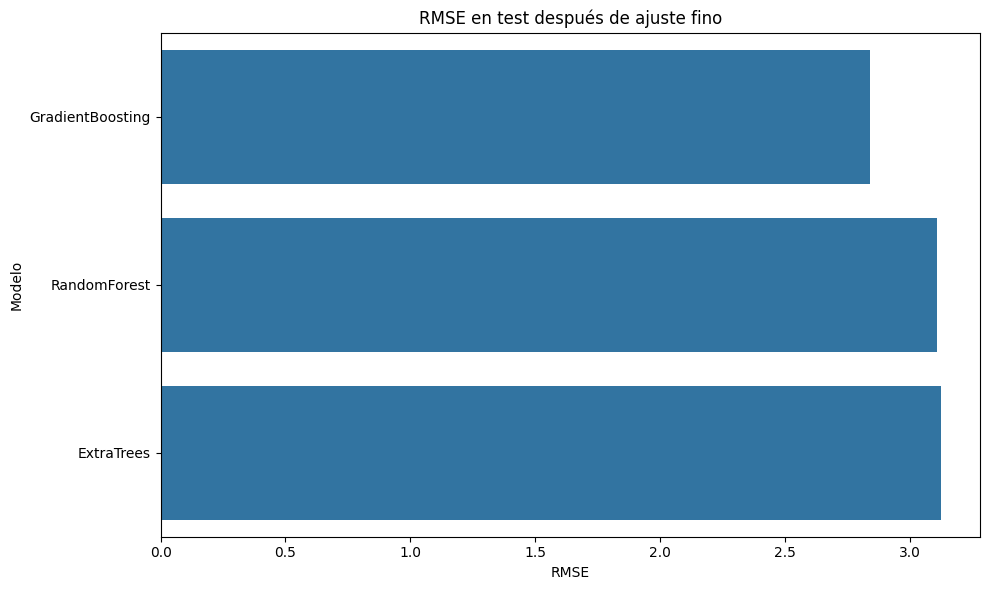

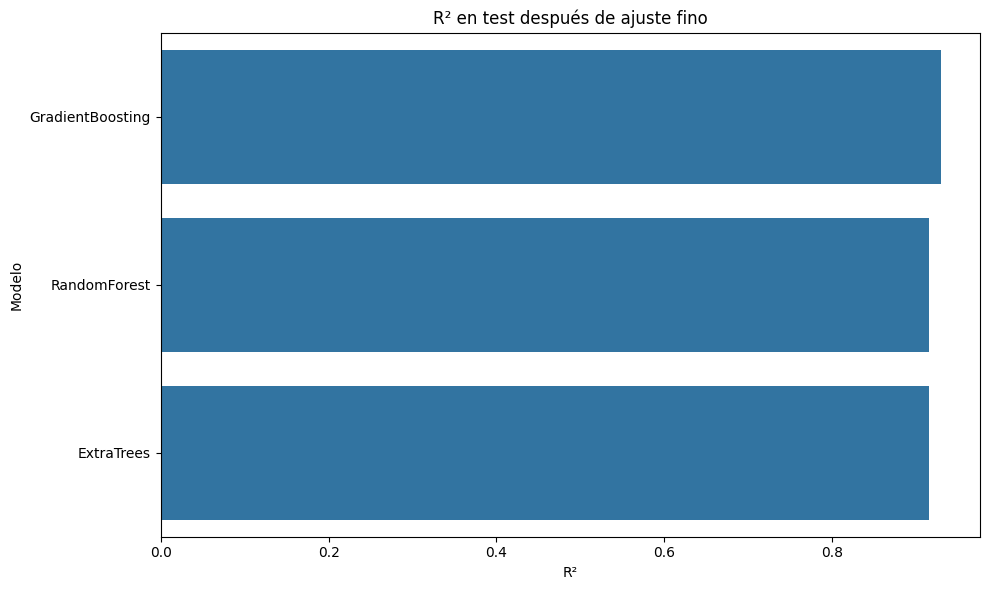

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=tuning_results_df, x="test_RMSE", y="Modelo")
plt.title("RMSE en test después de ajuste fino")
plt.xlabel("RMSE")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=tuning_results_df, x="test_R2", y="Modelo")
plt.title("R² en test después de ajuste fino")
plt.xlabel("R²")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


## 17. Selección del mejor modelo final


In [17]:
best_row = tuning_results_df.iloc[0]
best_model_name = best_row["Modelo"]
best_model = best_estimators[best_model_name]

print("Mejor modelo afinado:")
display(best_row)


Mejor modelo afinado:


Modelo                                           GradientBoosting
best_cv_rmse                                             3.510693
test_MAE                                                 2.223652
test_RMSE                                                2.843031
test_R2                                                  0.929402
best_params     {'model__learning_rate': 0.05, 'model__max_dep...
Name: 0, dtype: object

## 18. Predicción real vs predicha del mejor modelo


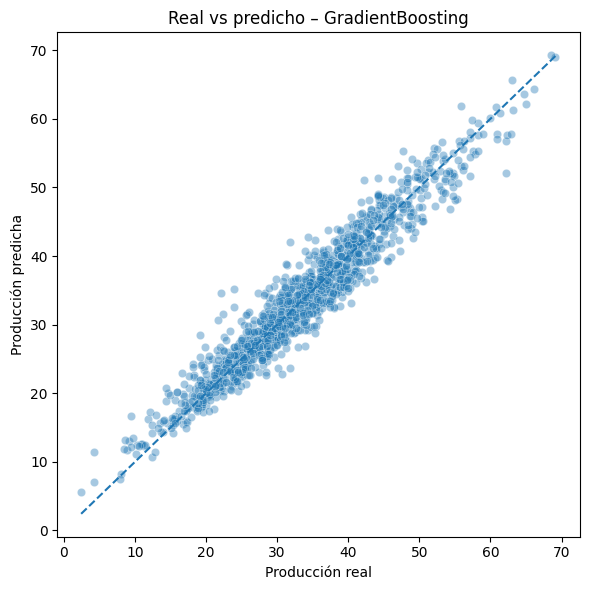

In [18]:
best_pred = best_model.predict(X_test)

comparison_plot_df = pd.DataFrame({
    "real": y_test.values,
    "predicho": best_pred
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparison_plot_df, x="real", y="predicho", alpha=0.4)
plt.title(f"Real vs predicho – {best_model_name}")
plt.xlabel("Producción real")
plt.ylabel("Producción predicha")

min_val = min(comparison_plot_df["real"].min(), comparison_plot_df["predicho"].min())
max_val = max(comparison_plot_df["real"].max(), comparison_plot_df["predicho"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()


## 19. Residuales del mejor modelo


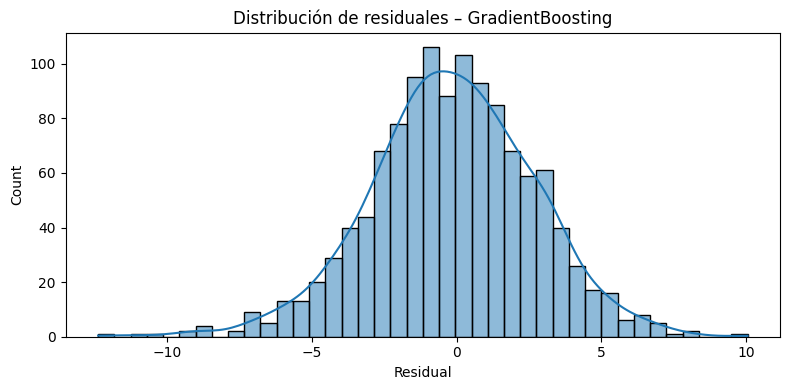

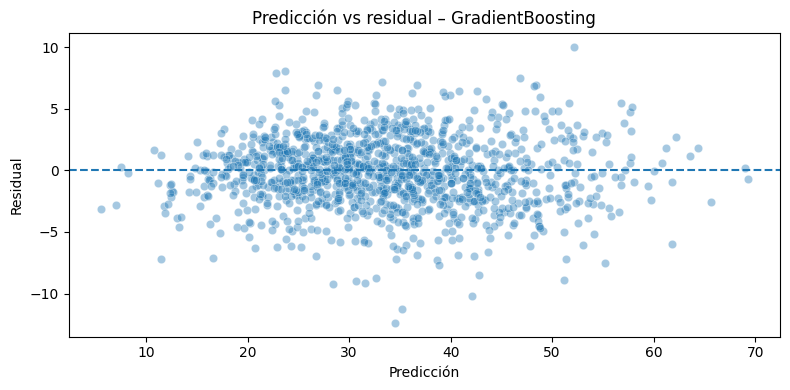

In [19]:
residuals = y_test.values - best_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title(f"Distribución de residuales – {best_model_name}")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title(f"Predicción vs residual – {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 20. Importancia de variables del mejor modelo (si aplica)


,feature,importance
0,num__produccion_roll_mean_3,0.466647
2,num__delta_produccion_1d,0.337546
3,num__delta_produccion_3d,0.179466
1,num__produccion_roll_std_3,0.012212
20,num__THI,0.000496
7,num__sobrante_roll_mean_3,0.000406
23,num__THI_roll_mean_7,0.000312
4,num__consumo,0.000303
21,num__THI_lag_1,0.000291
9,num__rechazo_roll_mean_3,0.000287


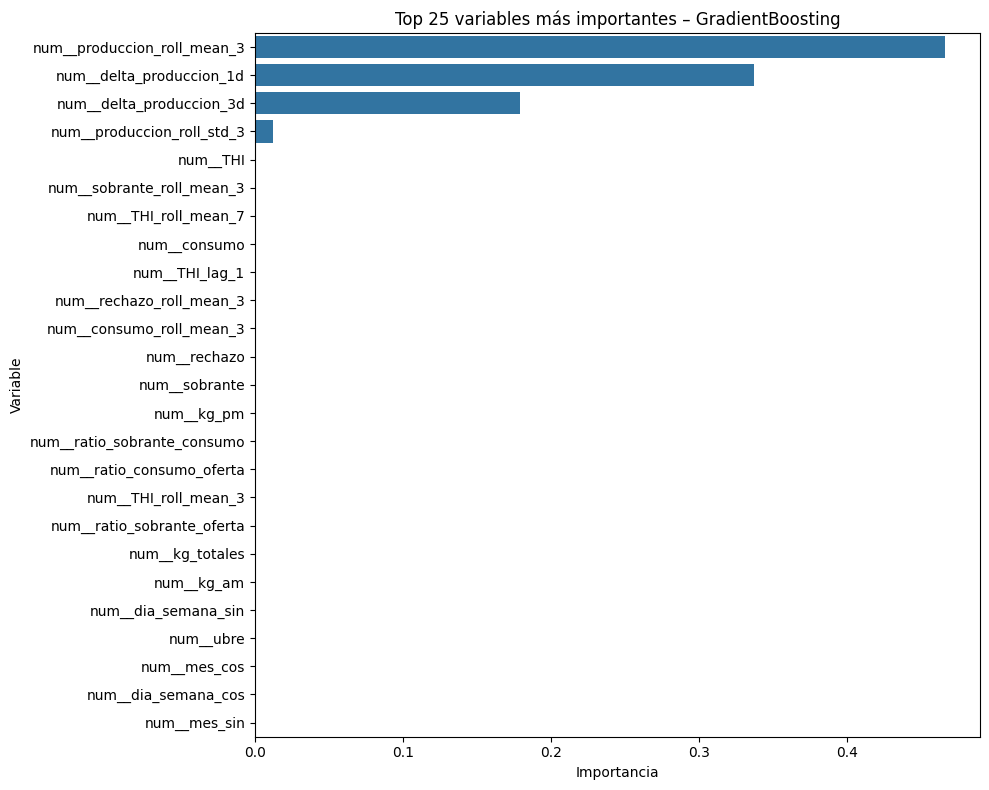

In [20]:
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = model_step.feature_importances_

    fi = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(25)
    )

    display(fi)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi, x="importance", y="feature")
    plt.title(f"Top 25 variables más importantes – {best_model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()
else:
    print(f"El modelo {best_model_name} no expone feature_importances_.")


## 21. Resumen final

Se presenta un resumen compacto del modelo final seleccionado.


In [21]:
print("Modelo final seleccionado:", best_model_name)
print("Parámetros óptimos:")
print(grid_objects[best_model_name].best_params_)

final_metrics = evaluate_regression(y_test, best_pred)
print("\nMétricas finales en test:")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")


Modelo final seleccionado: GradientBoosting
Parámetros óptimos:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}

Métricas finales en test:
MAE: 2.2237
RMSE: 2.8430
R2: 0.9294


## 22. Conclusiones

En este notebook se realizó ajuste fino de hiperparámetros sobre varios modelos basados en árboles.

### Logros principales

- comparación de modelos base
- búsqueda de hiperparámetros con validación temporal
- evaluación sobre conjunto de test
- selección del mejor modelo final
- análisis visual de ajuste y residuales
- importancia de variables si el modelo lo permite

### Próximos pasos sugeridos

1. reducir o refinar el espacio de búsqueda para el mejor modelo  
2. comparar explícitamente con y sin variables de alimentación  
3. evaluar desempeño por vaca  
4. guardar el pipeline final entrenado  
5. crear un notebook de interpretación del modelo final
